# Nama : I Made Bimantoro Mastra
# Assignment : Advanced Techniques in Python Data Visualization

---
## 1. Eksplorasi Data untuk Visualisasi

**Goal:** Memahami dataset sebelum membuat visualisasi yang bermakna.

In [ ]:
# Import library yang dibutuhkan
import pandas as pd              # Untuk baca & olah data tabular (dataframe).
import numpy as np               # Untuk operasi numerik (angka, NaN, dll).
import matplotlib.pyplot as plt  # Untuk membuat grafik dasar.
import seaborn as sns            # Untuk membuat grafik statistik yang lebih 'cantik' & mudah.
import plotly.express as px      # Untuk membuat grafik interaktif secara cepat dan mudah.

# Setting tampilan grafik biar konsisten di seluruh notebook
sns.set_style('whitegrid')               # background putih dengan garis grid tipis, biar enak dibaca
plt.rcParams['figure.figsize'] = (8, 5)  # ukuran default semua figure: lebar 8, tinggi 5

# Membaca file CSV
df = pd.read_csv('/content/sample_data/Telco_customer_churn.csv')

print("✅ All libraries and datasets loaded!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/Telco_customer_churn.csv'

In [ ]:

# Cek ukuran dataset: (jumlah baris, jumlah kolom).
print('Ukuran dataset:', df.shape)

# Tampilkan 5 baris pertama.
df.head()

Ukuran dataset: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
# Cek struktur dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Internet Service']

NameError: name 'df' is not defined

In [ ]:
# Cek berapa banyak null.
missing = df.isnull().sum()

# Tampilkan kolom yang punya missing value.
missing[missing > 0]

,0
Churn Reason,5174


`df.isnull()` untuk melihat kolom kosong. `.sum()` menjumlahkan `True` per kolom.

Hasilnya: kolom `Churn Reason` punya banyak nilai kosong. Tapi ini bukan data rusa, tetapi kolom ini memang cuma diisi kalau pelanggan berhenti berlangganan (churn).*italicised text*

In [ ]:
# Cek kolom Total Charges.
print(df['Total Charges'].dtype)

# Coba ubah ke angka; errors='coerce' nilai yang gagal dikonveri jadikan NaN (kosong).
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Cek ulang, ada berapa baris yang sekarang jadi NaN gara-gara konversi ini.
print('Jumlah nilai kosong setelah konversi:', df['Total Charges'].isnull().sum())

# Lihat baris-baris tersebut.
df[df['Total Charges'].isnull()][['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges']]

object
Jumlah nilai kosong setelah konversi: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,NaN
2438,3115-CZMZD,0,20.25,NaN
2568,5709-LVOEQ,0,80.85,NaN
2667,4367-NUYAO,0,25.75,NaN
2856,1371-DWPAZ,0,56.05,NaN
4331,7644-OMVMY,0,19.85,NaN
4687,3213-VVOLG,0,25.35,NaN
5104,2520-SGTTA,0,20.00,NaN
5719,2923-ARZLG,0,19.70,NaN
6772,4075-WKNIU,0,73.35,NaN


`Total Charges` awalnya terbaca sebagai teks (`object`) karena ada 11 baris yang isinya string kosong `' '` (bukan angka). Setelah dicek, ternyata semua 11 baris ini adalah pelanggan dengan **`Tenure Months` = 0**, alias pelanggan yang baru saja daftar dan belum genap 1 bulan berlangganan, masuk akal kalau total tagihan mereka belum tercatat.

ganti nilai kosong itu menjadi **0**, karena secara logika bisnis, pelanggan yang baru gabung 0 bulan memang belum ditagih apa-apa.

In [ ]:
# Isi nilai kosong di 'Total Charges' dengan 0 (pelanggan baru, belum ada tagihan).
df['Total Charges'] = df['Total Charges'].fillna(0)

# Verifikasi sudah tidak ada missing value lagi di kolom ini.
print('Sisa missing value di Total Charges:', df['Total Charges'].isnull().sum())

Sisa missing value di Total Charges: 0


In [ ]:
# Identifikasi kolom numerik vs kategorikal, supaya nanti gampang milih jenis visualisasi.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Kolom numerik:', numeric_cols)
print()
print('Kolom kategorikal:', categorical_cols)

Kolom numerik: ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']

Kolom kategorikal: ['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label', 'Churn Reason']


`select_dtypes` memilih kolom berdasarkan tipe datanya. Membedakan kolom numerik dan kategorikal itu penting karena **jenis visualisasi yang cocok berbeda**:
- Kolom numerik (angka) cocok untuk histogram, boxplot, scatter plot
- Kolom kategorikal (teks/kategori) cocok untuk bar chart / count plot

Kolom yang paling relevan untuk analisis churn adalah: `Tenure Months`, `Monthly Charges`, `Total Charges`, `Churn Score`, `CLTV` (numerik), serta `Contract`, `Internet Service`, `Payment Method`, `Churn Label` (kategorikal). Kolom seperti `CustomerID`, `Lat Long`, `Zip Code` tidak terlalu berguna untuk visualisasi insight bisnis.

In [ ]:
# Ringkasan statistik deskriptif untuk kolom numerik yang relevan.
kolom_relevan = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']
df[kolom_relevan].describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,58.699418,4400.295755
std,24.559481,30.090047,2266.794470,21.525131,1183.057152
min,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,9.000000,35.500000,398.550000,40.000000,3469.000000
50%,29.000000,70.350000,1394.550000,61.000000,4527.000000
75%,55.000000,89.850000,3786.600000,75.000000,5380.500000
max,72.000000,118.750000,8684.800000,100.000000,6500.000000


Dataset sudah bersih dan siap divisualisasikan. `Total Charges` sudah jadi angka dan tidak ada nilai kosong yang mengganggu, sementara nilai kosong di `Churn Reason` memang wajar secara bisnis (bukan error) dan kita biarkan apa adanya.

---
## 2. Visualisasi Distribusi Data

**Goal:** Memahami sebaran data dan mendeteksi adanya outlier atau pola tertentu.


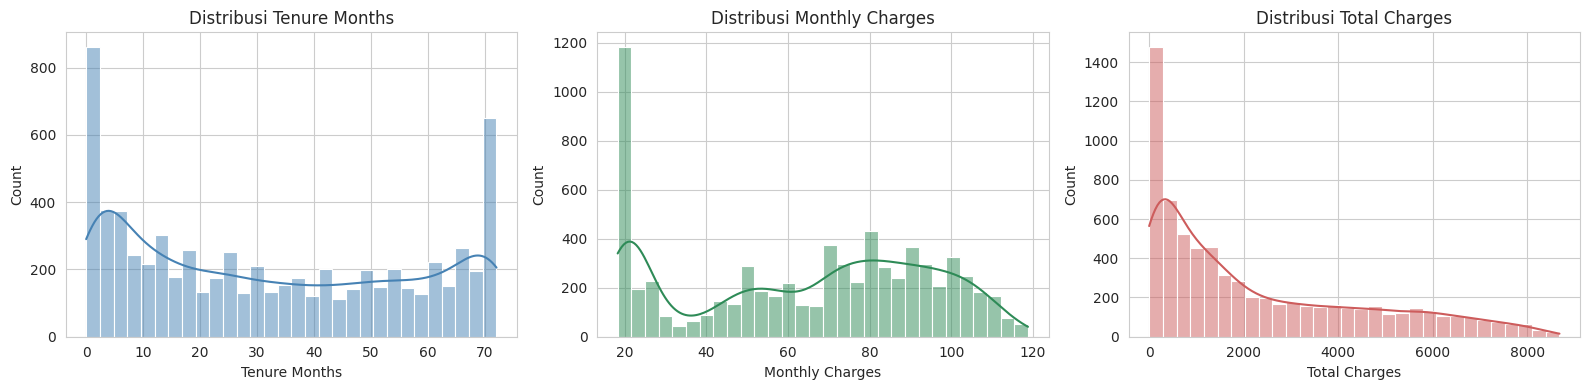

In [ ]:
# Membuat histogram untuk melihat sebaran (distribusi) 3 variabel numerik utama.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # 1 baris, 3 kolom subplot berdampingan.

# Histogram Tenure Months (lama berlangganan dalam bulan).
sns.histplot(df['Tenure Months'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Tenure Months')

# Histogram Monthly Charges (tagihan bulanan).
sns.histplot(df['Monthly Charges'], bins=30, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribusi Monthly Charges')

# Histogram Total Charges (total tagihan sepanjang berlangganan).
sns.histplot(df['Total Charges'], bins=30, kde=True, ax=axes[2], color='indianred')
axes[2].set_title('Distribusi Total Charges')

plt.tight_layout()  # rapikan jarak antar subplot biar tidak tumpang tindih.
plt.show()

**Penjelasan:** `sns.histplot()` membagi data jadi beberapa 'kotak' (bins) dan menghitung berapa banyak data yang jatuh di tiap kotak(histogram). Parameter `kde=True` menambahkan garis halus (Kernel Density Estimate), semacam versi 'diperhalus' dari histogram supaya bentuk distribusinya lebih jelas terlihat.

**INSIGHT:**
- `Tenure Months` punya dua 'puncak' (bimodal) banyak pelanggan yang baru gabung (dekat 0 bulan) dan banyak juga yang sudah lama (dekat 72 bulan). Artinya ada dua kelompok besar: pelanggan baru dan pelanggan setia jangka panjang.
- `Monthly Charges` juga polanya sama, dengan banyak pelanggan di tagihan rendah (20) dan gerombolan lain di tagihan tinggi (70-100).
- `Total Charges` miring ke kanan (*right-skewed*), karena ini hasil perkalian tagihan bulanan × lama berlangganan, jadi pelanggan lama otomatis totalnya jauh lebih besar.

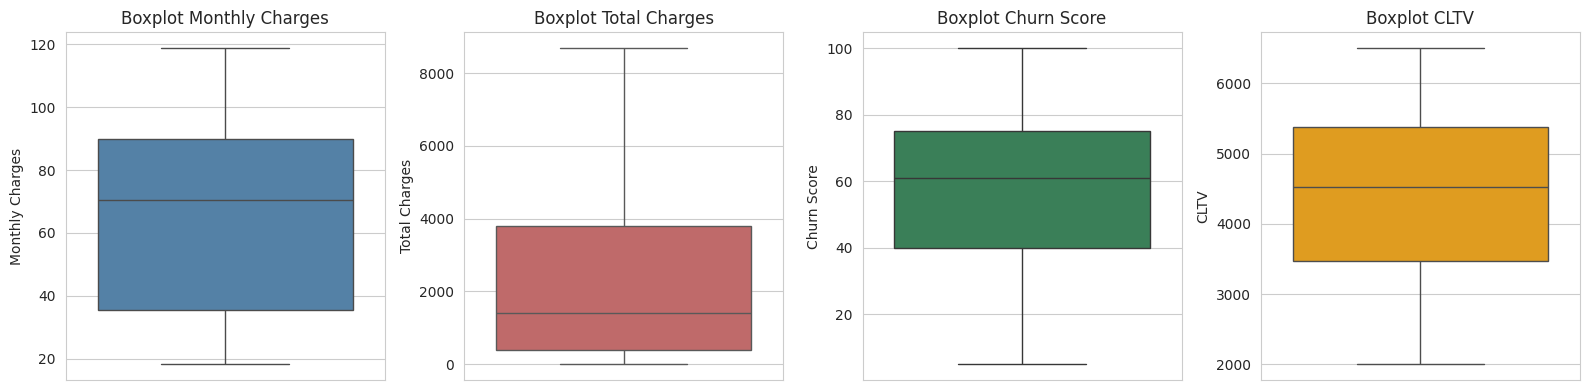

In [ ]:
# Membuat boxplot untuk mendeteksi outlier pada variabel numerik.
fig, axes = plt.subplots(1, 4, figsize=(16, 4)) # 1 baris, 4 kolom subplot berdampingan.

kolom_box = ['Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']
warna = ['steelblue', 'indianred', 'seagreen', 'orange']

# Loop untuk membuat boxplot satu per satu di tiap subplot.
for ax, kolom, warna_i in zip(axes, kolom_box, warna):
    sns.boxplot(y=df[kolom], ax=ax, color=warna_i)
    ax.set_title(f'Boxplot {kolom}')

plt.tight_layout()
plt.show()

**INSIGHT:** `Monthly Charges`, `Total Charges`, dan `Churn Score` tidak menunjukkan outlier ekstrem karna persebarannya cukup wajar/proporsional. `CLTV` (Customer Lifetime Value) sedikit lebih lebar rentangnya tapi masih dalam batas wajar.

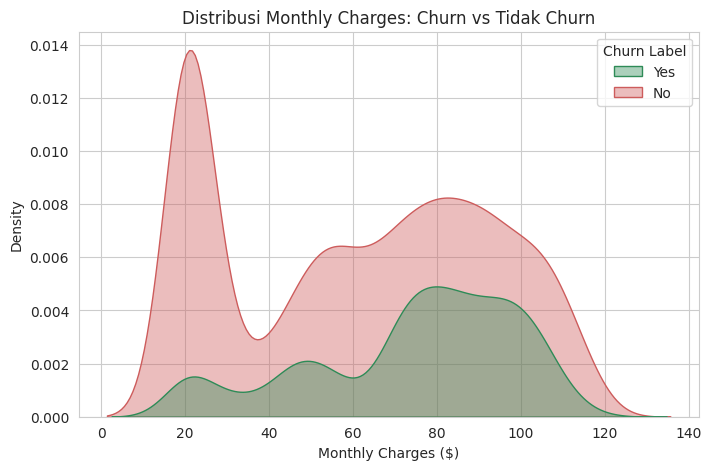

In [ ]:
# KDE plot untuk membandingkan bentuk distribusi Monthly Charges antar status Churn.
plt.figure(figsize=(8, 5))

# KDE terpisah untuk pelanggan yang churn vs tidak churn, ditumpuk dalam satu grafik.
sns.kdeplot(data=df, x='Monthly Charges', hue='Churn Label', fill=True, alpha=0.4, palette=['seagreen', 'indianred'])

plt.title('Distribusi Monthly Charges: Churn vs Tidak Churn')
plt.xlabel('Monthly Charges ($)')
plt.show()

`fill=True` mewarnai area di bawah kurva agar lebih mudah dibaca.

**INSIGHT:** Pelanggan yang **churn (berhenti)** cenderung punya `Monthly Charges` yang lebih tinggi (kurva merah condong ke kanan), sementara pelanggan yang **tidak churn** lebih banyak berada di tagihan rendah (kurva hijau menumpuk di sekitar $20). Artinya tagihan bulanan yang tinggi mungkin berkaitan dengan keputusan pelanggan untuk berhenti berlangganan.

**Kesimpulan Bagian 2:** Distribusi data secara umum wajar tanpa outlier ekstrem, tapi pola *bimodal* pada Tenure & Monthly Charges, serta perbedaan distribusi berdasarkan status churn.

---
## 3. Visualisasi Data Bivariat

**Goal:** Mengetahui bagaimana dua variabel berkorelasi satu sama lain.


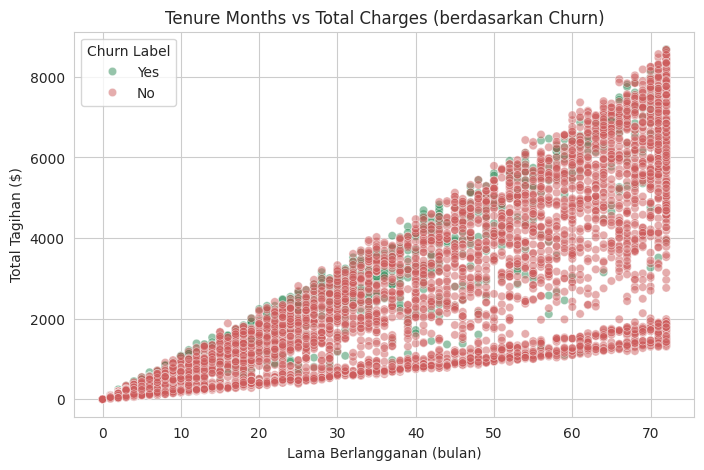

In [ ]:
# Scatter plot: hubungan antara Tenure Months dan Total Charges, diwarnai berdasarkan status Churn.
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Tenure Months', y='Total Charges', hue='Churn Label',
                 alpha=0.5, palette=['seagreen', 'indianred'])

plt.title('Tenure Months vs Total Charges (berdasarkan Churn)')
plt.xlabel('Lama Berlangganan (bulan)')
plt.ylabel('Total Tagihan ($)')
plt.show()

`Tenure Months` (sumbu x) dan `Total Charges` (sumbu y). `hue='Churn Label'` mewarnai titik berdasarkan status churn, dan `alpha=0.5` membuat titik agak transparan supaya kalau ada banyak titik menumpuk, kita masih bisa lihat 'kepadatan'-nya.

**INSIGHT:** Pola **korelasi positif** makin lama pelanggan berlangganan (`Tenure Months` besar), makin besar juga `Total Charges`. Ini logis karena total tagihan adalah akumulasi dari tagihan bulanan. Titik-titik merah (churn) lebih terkonsentrasi di **tenure rendah** (kiri bawah) artinya pelanggan yang baru berlangganan lebih rentan berhenti dibanding pelanggan lama.

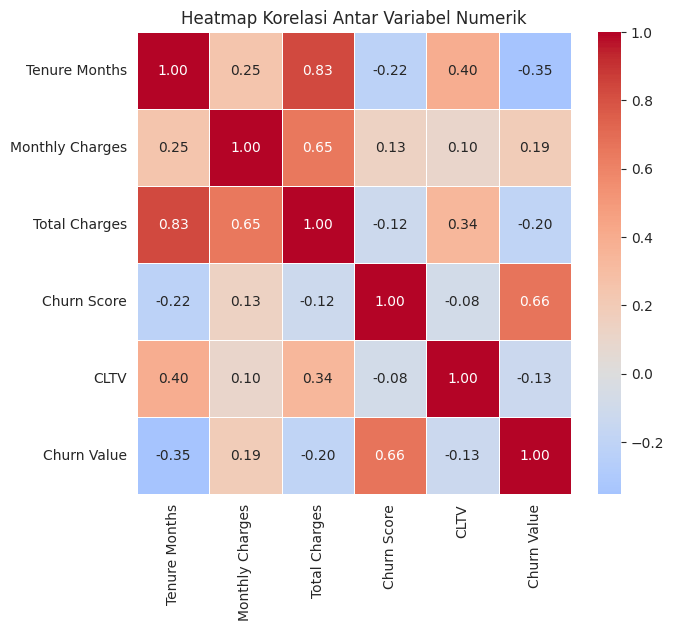

In [ ]:
# Heatmap korelasi antar variabel numerik.
kolom_numerik = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV', 'Churn Value']

# Hitung matriks korelasi (nilai antara -1 sampai 1).
corr_matrix = df[kolom_numerik].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

**INSIGHT:**
- `Tenure Months` dan `Total Charges` punya korelasi **sangat kuat positif** (mendekati +1).
- `Churn Score` berkorelasi positif dengan `Churn Value`.
- `Tenure Months` berkorelasi **negatif** dengan `Churn Value` karna semakin lama berlangganan, semakin kecil kemungkinan churn. Ini insight bisnis yang penting: program loyalitas untuk pelanggan baru bisa jadi strategi yang efektif.

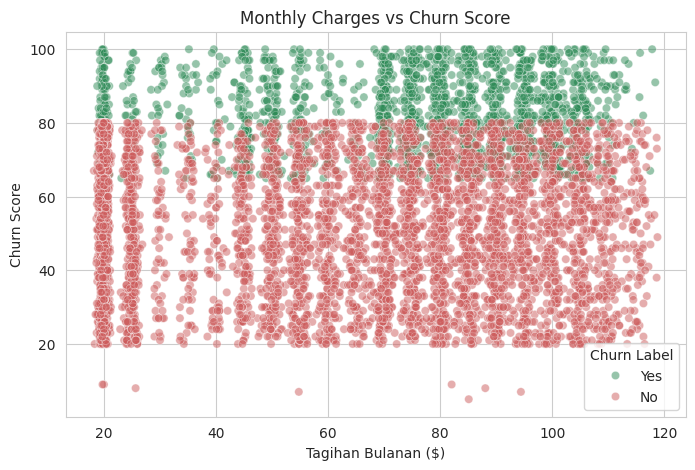

In [ ]:
# Scatter plot tambahan: Monthly Charges vs Churn Score.
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='Monthly Charges', y='Churn Score', hue='Churn Label',
                 alpha=0.5, palette=['seagreen', 'indianred'])

plt.title('Monthly Charges vs Churn Score')
plt.xlabel('Tagihan Bulanan ($)')
plt.ylabel('Churn Score')
plt.show()

**INSIGHT:** Semakin tinggi `Monthly Charges`, cenderung semakin tinggi juga `Churn Score`-nya (skor risiko churn dari sistem). Tagihan bulanan yang mahal berasosiasi dengan risiko churn yang lebih tinggi.

**INSIGHT Bagian 3:** Dua pola bivariat utama ditemukan: (1) `Tenure Months` berkorelasi kuat positif dengan `Total Charges` (wajar secara matematis), dan (2) `Tenure Months` yang rendah serta `Monthly Charges` yang tinggi berasosiasi dengan risiko churn yang lebih besar.

---
## 4. Visualisasi Data Kategorikal

**Goal:** Memahami bagaimana data kategorikal terdistribusi dan hubungannya dengan variabel lain.


/tmp/ipykernel_709/209439501.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn Label', palette=['seagreen', 'indianred'])


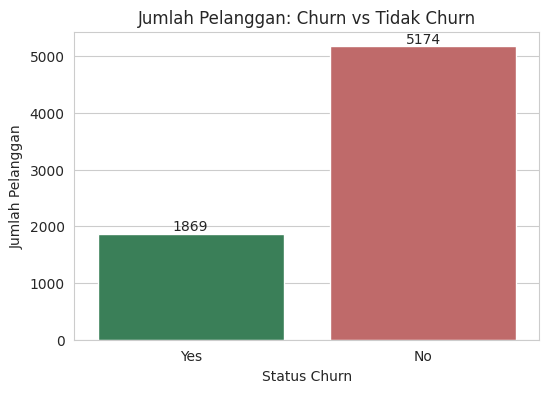

In [ ]:
# Countplot: perbandingan jumlah pelanggan yang churn vs tidak.
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x='Churn Label', palette=['seagreen', 'indianred'])
plt.title('Jumlah Pelanggan: Churn vs Tidak Churn')
plt.xlabel('Status Churn')
plt.ylabel('Jumlah Pelanggan')

# Tambahkan label angka di atas tiap bar biar lebih informatif.
for container in ax.containers:
    ax.bar_label(container)

plt.show()

**INSIGHT:** `sns.countplot()` menghitung otomatis berapa kali tiap kategori muncul, lalu menampilkannya sebagai bar chart — tidak perlu kita hitung manual dulu. `ax.bar_label()` menambahkan angka jumlah tepat di atas tiap batang, biar pembaca tidak perlu menerka-nerka dari tinggi batang saja.

**INSIGHT:** Dari 7.043 pelanggan, sekitar 1.869 (±27%) churn dan sisanya bertahan. Proporsi ini penting diketahui — kalau nanti data ini dipakai untuk model prediksi, kita sudah tahu datanya agak *imbalanced* (tidak seimbang 50:50).

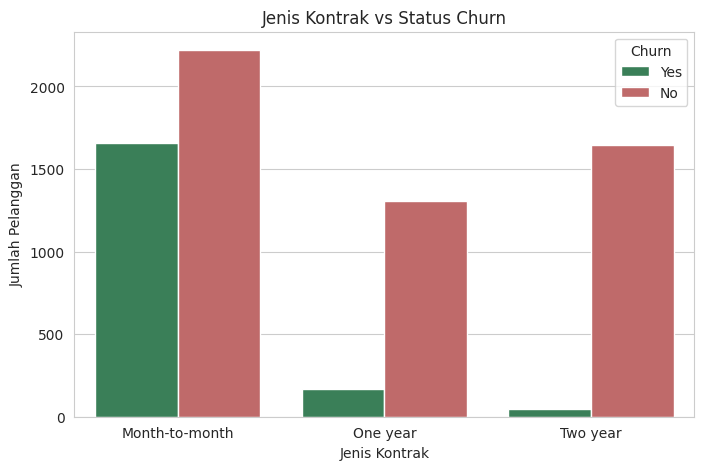

In [ ]:
# Countplot: distribusi Contract, dipecah berdasarkan status Churn.
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='Contract', hue='Churn Label', palette=['seagreen', 'indianred'],
                    order=['Month-to-month', 'One year', 'Two year'])

plt.title('Jenis Kontrak vs Status Churn')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Jumlah Pelanggan')
plt.legend(title='Churn')
plt.show()

**Penjelasan:** `hue='Churn Label'` memecah tiap kategori kontrak jadi dua batang berdampingan (churn vs tidak), sehingga kita bisa bandingkan proporsinya. `order=[...]` memastikan urutan kategori di sumbu-x logis (bulanan → 1 tahun → 2 tahun), bukan urutan acak/alfabetis.

**Interpretasi:** Ini salah satu temuan paling kuat di dataset ini — pelanggan dengan kontrak **`Month-to-month` (bulanan)** punya jumlah churn yang jauh lebih tinggi dibanding kontrak `One year` atau `Two year`. Masuk akal: kontrak bulanan lebih fleksibel untuk berhenti kapan saja, sementara kontrak jangka panjang biasanya sudah 'terikat' komitmen.

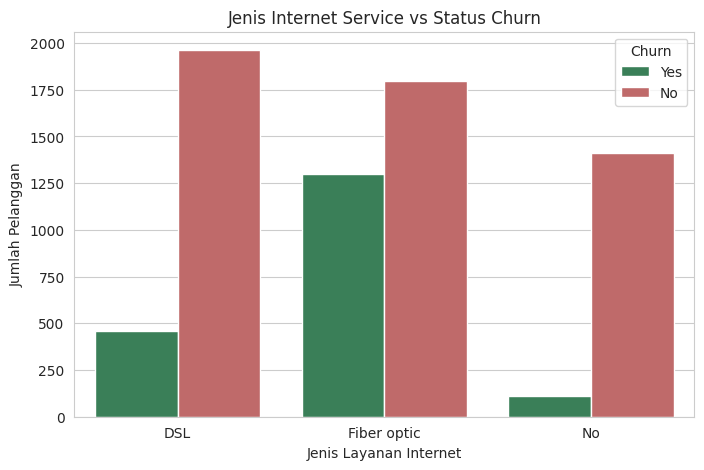

In [ ]:
# Countplot: distribusi Internet Service vs Churn.
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='Internet Service', hue='Churn Label', palette=['seagreen', 'indianred'])
plt.title('Jenis Internet Service vs Status Churn')
plt.xlabel('Jenis Layanan Internet')
plt.ylabel('Jumlah Pelanggan')
plt.legend(title='Churn')
plt.show()

**Interpretasi:** Pelanggan dengan layanan **Fiber optic** punya jumlah churn yang cukup tinggi dibanding DSL, meskipun secara umum fiber optic juga merupakan layanan paling populer. Ini bisa jadi berkaitan dengan temuan sebelumnya — fiber optic biasanya berbanding lurus dengan `Monthly Charges` yang lebih mahal, dan kita sudah tahu tagihan mahal berasosiasi dengan churn lebih tinggi.

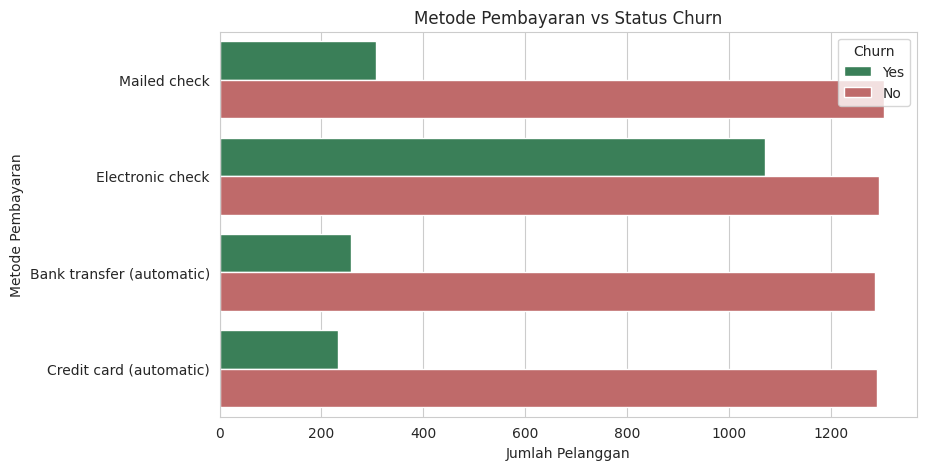

In [ ]:
# Countplot: distribusi Payment Method.
plt.figure(figsize=(9, 5))

ax = sns.countplot(data=df, y='Payment Method', hue='Churn Label', palette=['seagreen', 'indianred'])
plt.title('Metode Pembayaran vs Status Churn')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Metode Pembayaran')
plt.legend(title='Churn')
plt.show()

**INSIGHT:** Pelanggan yang membayar dengan **Electronic check** punya proporsi churn yang jauh lebih tinggi dibanding metode pembayaran otomatis (Bank transfer / Credit card automatic). Metode pembayaran manual seperti electronic check biasanya dipakai pelanggan yang belum terlalu berkomitmen jangka panjang dengan penyedia layanan.

**INSIGHT Bagian 4:** Tiga variabel kategorikal **jenis kontrak, jenis layanan internet, dan metode pembayaran** semuanya menunjukkan pola yang jelas terhadap churn, dan menjadi kandidat kuat sebagai faktor pendorong pelanggan berhenti berlangganan.

---
## 5. Data Storytelling dengan Visualisasi

**Goal:** Mengkomunikasikan hasil analisis dengan cara yang menarik dan mudah dipahami.

/tmp/ipykernel_709/2525607622.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y='Tenure Months', ax=axes[1, 0], palette=['seagreen', 'indianred'])
/tmp/ipykernel_709/2525607622.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', ax=axes[1, 1], palette=['seagreen', 'indianred'])


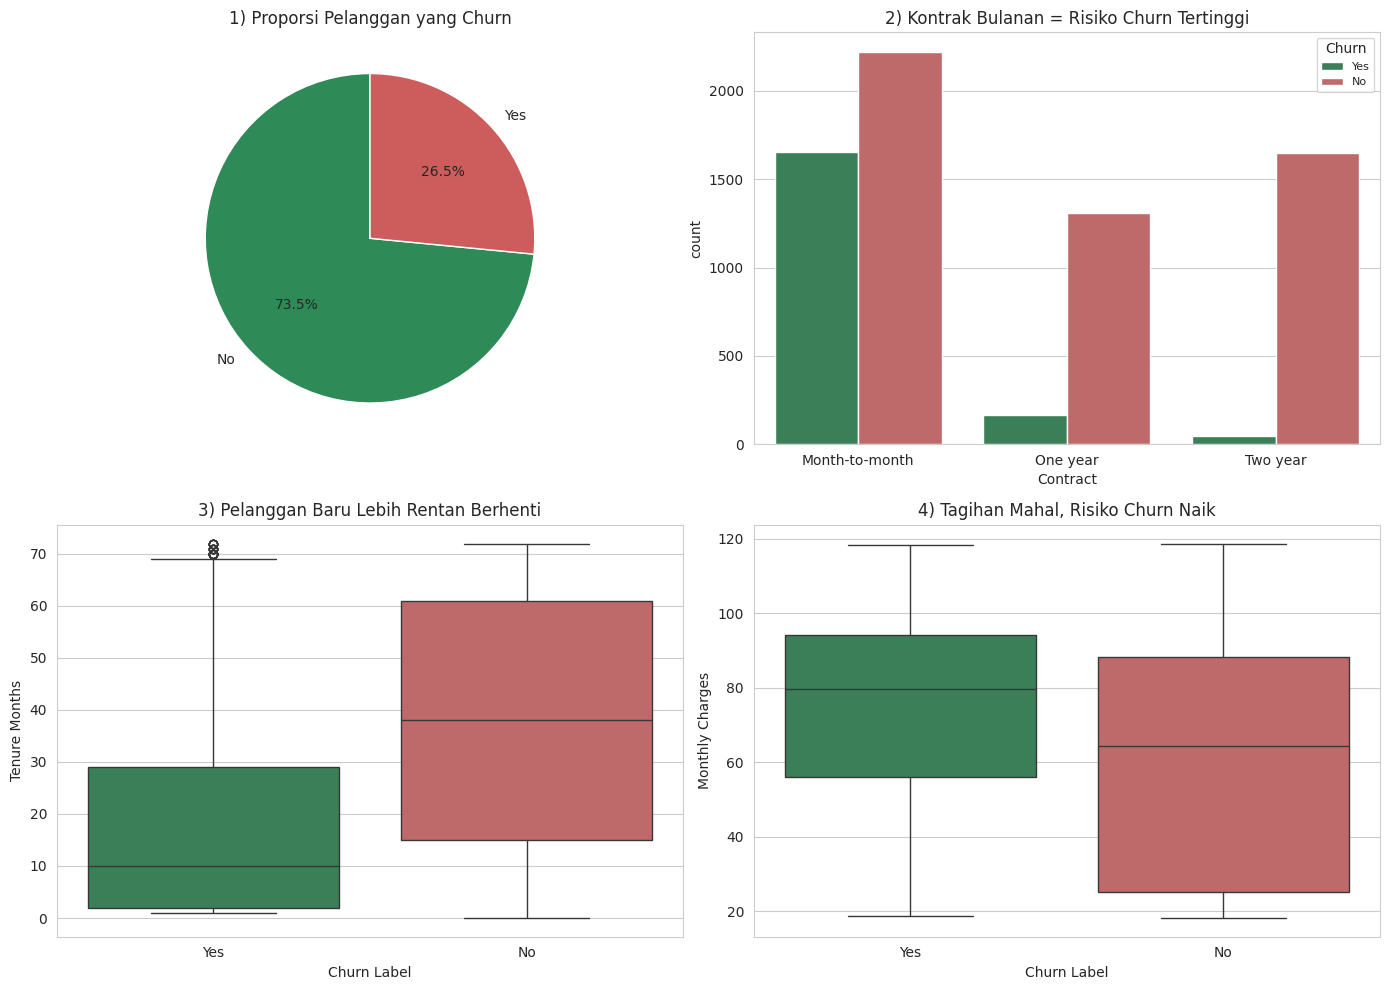

In [ ]:
# Membuat dashboard gabungan (2x2) untuk menyampaikan cerita utama tentang churn.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Proporsi churn keseluruhan.
churn_counts = df['Churn Label'].value_counts()
axes[0, 0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
               colors=['seagreen', 'indianred'], startangle=90)
axes[0, 0].set_title('1) Proporsi Pelanggan yang Churn')

# Panel 2: Churn berdasarkan jenis kontrak.
sns.countplot(data=df, x='Contract', hue='Churn Label', ax=axes[0, 1],
              palette=['seagreen', 'indianred'], order=['Month-to-month', 'One year', 'Two year'])
axes[0, 1].set_title('2) Kontrak Bulanan = Risiko Churn Tertinggi')
axes[0, 1].legend(title='Churn', fontsize=8)

# Panel 3: Tenure vs Churn (boxplot).
sns.boxplot(data=df, x='Churn Label', y='Tenure Months', ax=axes[1, 0], palette=['seagreen', 'indianred'])
axes[1, 0].set_title('3) Pelanggan Baru Lebih Rentan Berhenti')

# Panel 4: Monthly Charges vs Churn (boxplot).
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', ax=axes[1, 1], palette=['seagreen', 'indianred'])
axes[1, 1].set_title('4) Tagihan Mahal, Risiko Churn Naik')

plt.tight_layout()
plt.show()

**Penjelasan:** menggabungkan 4 grafik jadi satu dashboard 2x2 memakai `plt.subplots(2, 2, ...)`.
---

###  Story telling

Dari total **7.043 pelanggan**, sekitar **26,5% memilih berhenti berlangganan (churn)** jumlah yang cukup signifikan bagi bisnis manapun. Dari data ini menyimpan pola yang cukup jelasg **siapa** yang paling berisiko berhenti, dan **kenapa**.

**INSIGHT 1  Kontrak adalah kunci komitmen.**

Pelanggan dengan kontrak **bulanan (month-to-month)** jauh lebih sering berhenti dibanding pelanggan dengan kontrak 1 atau 2 tahun. Ini terjadi karna kontrak jangka pendek tidak punya 'pengikat' apapun untuk bertahan, sementara kontrak jangka panjang biasanya sudah menyertakan komitmen (dan mungkin insentif) untuk tetap tinggal.

**INSIGHT 2  Bulan-bulan awal adalah masa paling rawan.**

Pelanggan yang churn cenderung memiliki `Tenure Months` yang jauh lebih rendah dibanding yang bertahan. Artinya, **masa-masa awal berlangganan adalah periode paling kritis** kalau pelanggan berhasil dipertahankan melewati beberapa bulan pertama, kemungkinan mereka bertahan lebih lama jauh lebih besar.

**INSIGHT 3  Harga yang mahal, tanpa loyalitas, jadi kombinasi berbahaya.**

Pelanggan yang churn juga cenderung membayar `Monthly Charges` yang lebih tinggi kemungkinan besar ini pelanggan layanan **Fiber optic** yang biayanya lebih mahal dari DSL. Kombinasi *tagihan mahal + belum ada rasa loyal (tenure rendah) + tidak terikat kontrak* menjadi akibat yang paling berisiko membuat pelanggan pergi.

**Kesimpulan & rekomendasi bisnis:**
-  Fokuskan program retensi pada pelanggan baru dengan kontrak bulanan di 3–6 bulan pertama mereka berlangganan karna itu periode yang paling rawan.
-  Pertimbangkan insentif migrasi dari kontrak bulanan ke kontrak tahunan (misalnya diskon), karena data menunjukkan kontrak panjang jauh lebih 'aman' dari churn.
-  Evaluasi kembali struktur harga layanan Fiber optic, atau tambahkan value lebih (misalnya bundling Online Security/Tech Support) untuk pelanggan dengan tagihan tinggi supaya mereka merasa harga sebanding dengan manfaat yang didapat.
